In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

matches = pd.read_csv("matches_clean.csv")
ball_by_ball = pd.read_csv("ball_by_ball_clean.csv")

In [ ]:
TEAM_COLORS = {
    "Chennai Super Kings": "#FFFF00",
    "Mumbai Indians": "#004BA0",
    "Royal Challengers Bengaluru": "#EC1C24",
    "Kolkata Knight Riders": "#3A225D",
    "Sunrisers Hyderabad": "#FF822A",
    "Delhi Capitals": "#17449B",
    "Rajasthan Royals": "#FF69B4",
    "Punjab Kings": "#D71920",
    "Gujarat Titans": "#1B2133",
    "Lucknow Super Giants": "#00AEEF",
    "Deccan Chargers": "#1E88E5",
    "Pune Warriors India": "#5E35B1",
    "Gujarat Lions": "#FF9800"
}

In [ ]:
team_venues = pd.concat([
    matches[["team1", "venue"]]
        .rename(columns={"team1": "team"}),

    matches[["team2", "venue"]]
        .rename(columns={"team2": "team"})
])

team_venues.head()

,team,venue
0,Punjab Kings,Punjab Cricket Association Stadium
1,Mumbai Indians,Greenfield Intl Stadium
2,Chennai Super Kings,M. A. Chidambaram Stadium
3,Chennai Super Kings,DY Patil Stadium
4,Rajasthan Royals,Sawai Mansingh Stadium


In [ ]:
home_venues = (
    team_venues.groupby(["team", "venue"])
    .size()
    .reset_index(name="matches")
)

home_venues = (
    home_venues.sort_values(
        ["team", "matches"],
        ascending=[True, False]
    )
    .groupby("team")
    .head(1)
)

home_venues.head()

,team,venue,matches
11,Chennai Super Kings,M. A. Chidambaram Stadium,76
32,Deccan Chargers,Rajiv Gandhi Intl Cricket Stadium,23
35,Delhi Capitals,Arun Jaitley Stadium,96
62,Gujarat Lions,Narendra Modi Stadium,17
74,Gujarat Titans,Narendra Modi Stadium,12


In [ ]:
home_matches = home_venues[
    ["team", "venue", "matches"]
].rename(
    columns={"matches": "home_matches"}
)

home_matches.head()

,team,venue,home_matches
11,Chennai Super Kings,M. A. Chidambaram Stadium,76
32,Deccan Chargers,Rajiv Gandhi Intl Cricket Stadium,23
35,Delhi Capitals,Arun Jaitley Stadium,96
62,Gujarat Lions,Narendra Modi Stadium,17
74,Gujarat Titans,Narendra Modi Stadium,12


In [ ]:
home_wins = []

for _, row in home_matches.iterrows():

    team = row["team"]
    venue = row["venue"]

    wins = matches[
        (matches["winner"] == team)
        &
        (matches["venue"] == venue)
    ].shape[0]

    home_wins.append(
        [team, venue, wins]
    )

home_wins = pd.DataFrame(
    home_wins,
    columns=[
        "team",
        "venue",
        "home_wins"
    ]
)

home_wins.head()

,team,venue,home_wins
0,Chennai Super Kings,M. A. Chidambaram Stadium,39
1,Deccan Chargers,Rajiv Gandhi Intl Cricket Stadium,7
2,Delhi Capitals,Arun Jaitley Stadium,51
3,Gujarat Lions,Narendra Modi Stadium,10
4,Gujarat Titans,Narendra Modi Stadium,3


In [ ]:
venue_performance = home_matches.merge(
    home_wins[
        [
            "team",
            "home_wins"
        ]
    ],
    on="team",
    how="left"
)

venue_performance["home_wins"] = (
    venue_performance["home_wins"]
    .fillna(0)
)

venue_performance.head()

,team,venue,home_matches,home_wins
0,Chennai Super Kings,M. A. Chidambaram Stadium,76,39
1,Deccan Chargers,Rajiv Gandhi Intl Cricket Stadium,23,7
2,Delhi Capitals,Arun Jaitley Stadium,96,51
3,Gujarat Lions,Narendra Modi Stadium,17,10
4,Gujarat Titans,Narendra Modi Stadium,12,3


In [ ]:
venue_performance["home_win_pct"] = round(
    (
        venue_performance["home_wins"]
        /
        venue_performance["home_matches"]
    ) * 100,
    2
)

venue_performance.head()

,team,venue,home_matches,home_wins,home_win_pct
0,Chennai Super Kings,M. A. Chidambaram Stadium,76,39,51.32
1,Deccan Chargers,Rajiv Gandhi Intl Cricket Stadium,23,7,30.43
2,Delhi Capitals,Arun Jaitley Stadium,96,51,53.12
3,Gujarat Lions,Narendra Modi Stadium,17,10,58.82
4,Gujarat Titans,Narendra Modi Stadium,12,3,25.00


In [ ]:
venue_batting = (
    matches.groupby("venue")
    .agg(
        avg_match_runs=("match_total_runs", "mean"),
        total_matches=("match_id", "count")
    )
    .reset_index()
)

venue_batting.sort_values(
    "avg_match_runs",
    ascending=False
).head(10)

,venue,avg_match_runs,total_matches
12,MCA Stadium,312.254545,55
17,Wankhede Stadium,288.884615,104
10,JSCA Intl Stadium Complex,284.250000,28
8,Himachal Pradesh Cricket Association Stadium,279.259259,27
6,Ekana Cricket Stadium,277.820513,39
9,Holkar Cricket Stadium,275.384615,26
11,M. A. Chidambaram Stadium,273.700000,100
5,Eden Gardens,271.093750,96
16,Sawai Mansingh Stadium,270.240964,83
15,Rajiv Gandhi Intl Cricket Stadium,266.628866,97


In [ ]:
if "is_wicket" not in ball_by_ball.columns:

    ball_by_ball["is_wicket"] = np.where(
        ball_by_ball["wicket_status"] == "Wicket",
        1,
        0
    )

In [ ]:
venue_bowling = (
    ball_by_ball.groupby("venue")
    .agg(
        total_wickets=("is_wicket", "sum")
    )
    .reset_index()
)

venue_bowling.sort_values(
    "total_wickets",
    ascending=False
).head(10)

,venue,total_wickets
3,Chinnaswamy Stadium,789
0,Arun Jaitley Stadium,696
17,Wankhede Stadium,690
14,Punjab Cricket Association Stadium,664
15,Rajiv Gandhi Intl Cricket Stadium,634
5,Eden Gardens,631
11,M. A. Chidambaram Stadium,610
16,Sawai Mansingh Stadium,534
12,MCA Stadium,391
13,Narendra Modi Stadium,308


In [ ]:
venue_performance["venue_dominance_score"] = round(
    (
        venue_performance["home_win_pct"] * 0.5
    )
    +
    (
        venue_performance["home_wins"] * 0.5
    ),
    2
)

In [ ]:
venue_rankings = venue_performance.sort_values(
    "venue_dominance_score",
    ascending=False
)

venue_rankings.reset_index(
    drop=True,
    inplace=True
)

venue_rankings.insert(
    0,
    "rank",
    range(1, len(venue_rankings)+1)
)

venue_rankings.head(10)

,rank,team,venue,home_matches,home_wins,home_win_pct,venue_dominance_score
0,1,Punjab Kings,Punjab Cricket Association Stadium,95,54,56.84,55.42
1,2,Royal Challengers Bengaluru,Chinnaswamy Stadium,106,55,51.89,53.44
2,3,Delhi Capitals,Arun Jaitley Stadium,96,51,53.12,52.06
3,4,Chennai Super Kings,M. A. Chidambaram Stadium,76,39,51.32,45.16
4,5,Kolkata Knight Riders,Eden Gardens,77,38,49.35,43.68
5,6,Mumbai Indians,Wankhede Stadium,90,41,45.56,43.28
6,7,Rajasthan Royals,Sawai Mansingh Stadium,70,34,48.57,41.28
7,8,Sunrisers Hyderabad,Rajiv Gandhi Intl Cricket Stadium,50,27,54.00,40.50
8,9,Gujarat Lions,Narendra Modi Stadium,17,10,58.82,34.41
9,10,Pune Warriors India,MCA Stadium,16,7,43.75,25.38


In [ ]:
venue_rankings.head(15)

,rank,team,venue,home_matches,home_wins,home_win_pct,venue_dominance_score
0,1,Punjab Kings,Punjab Cricket Association Stadium,95,54,56.84,55.42
1,2,Royal Challengers Bengaluru,Chinnaswamy Stadium,106,55,51.89,53.44
2,3,Delhi Capitals,Arun Jaitley Stadium,96,51,53.12,52.06
3,4,Chennai Super Kings,M. A. Chidambaram Stadium,76,39,51.32,45.16
4,5,Kolkata Knight Riders,Eden Gardens,77,38,49.35,43.68
5,6,Mumbai Indians,Wankhede Stadium,90,41,45.56,43.28
6,7,Rajasthan Royals,Sawai Mansingh Stadium,70,34,48.57,41.28
7,8,Sunrisers Hyderabad,Rajiv Gandhi Intl Cricket Stadium,50,27,54.00,40.50
8,9,Gujarat Lions,Narendra Modi Stadium,17,10,58.82,34.41
9,10,Pune Warriors India,MCA Stadium,16,7,43.75,25.38


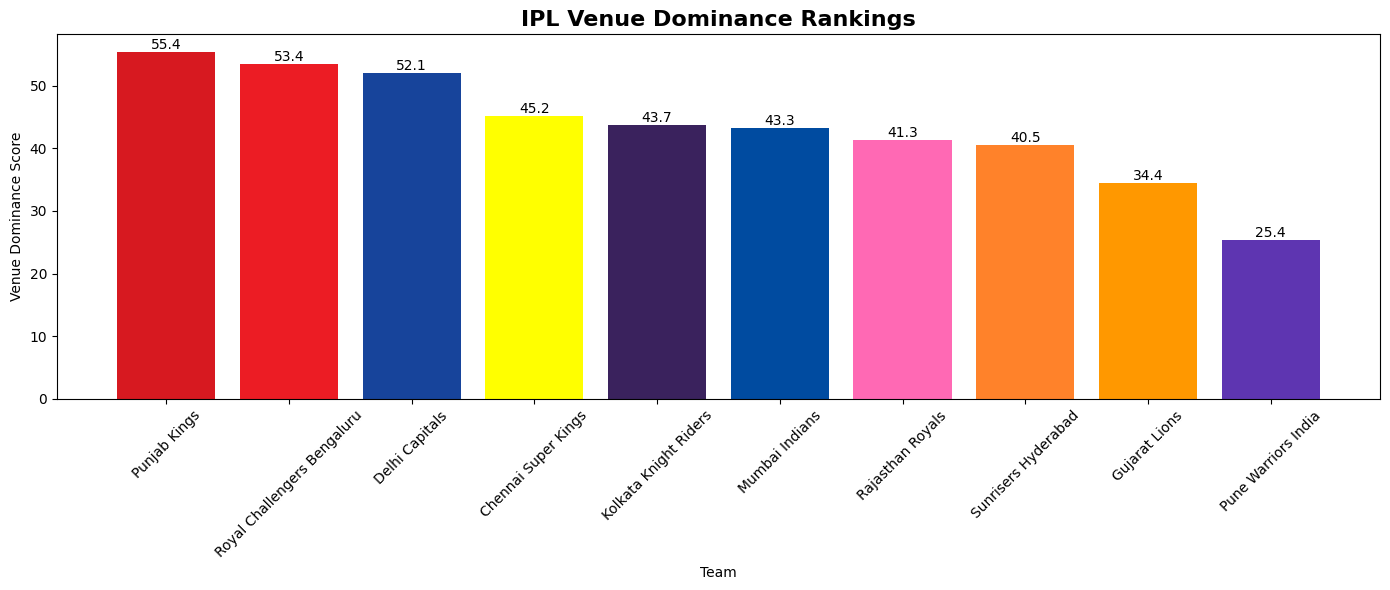

In [ ]:
top10 = venue_rankings.head(10)

colors = [
    TEAM_COLORS.get(team, "#808080")
    for team in top10["team"]
]

plt.figure(figsize=(14,6))

bars = plt.bar(
    top10["team"],
    top10["venue_dominance_score"],
    color=colors
)

plt.title(
    "IPL Venue Dominance Rankings",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Team")
plt.ylabel("Venue Dominance Score")

plt.xticks(rotation=45)

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.5,
        f"{bar.get_height():.1f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
venue_rankings = venue_rankings[
    [
        "rank",
        "team",
        "venue",
        "home_matches",
        "home_wins",
        "home_win_pct",
        "venue_dominance_score"
    ]
]

venue_rankings.head(10)

,rank,team,venue,home_matches,home_wins,home_win_pct,venue_dominance_score
0,1,Punjab Kings,Punjab Cricket Association Stadium,95,54,56.84,55.42
1,2,Royal Challengers Bengaluru,Chinnaswamy Stadium,106,55,51.89,53.44
2,3,Delhi Capitals,Arun Jaitley Stadium,96,51,53.12,52.06
3,4,Chennai Super Kings,M. A. Chidambaram Stadium,76,39,51.32,45.16
4,5,Kolkata Knight Riders,Eden Gardens,77,38,49.35,43.68
5,6,Mumbai Indians,Wankhede Stadium,90,41,45.56,43.28
6,7,Rajasthan Royals,Sawai Mansingh Stadium,70,34,48.57,41.28
7,8,Sunrisers Hyderabad,Rajiv Gandhi Intl Cricket Stadium,50,27,54.00,40.50
8,9,Gujarat Lions,Narendra Modi Stadium,17,10,58.82,34.41
9,10,Pune Warriors India,MCA Stadium,16,7,43.75,25.38


In [ ]:
venue_rankings.to_csv(
    "venue_dominance_rankings.csv",
    index=False
)

venue_batting.to_csv(
    "best_batting_venues.csv",
    index=False
)

venue_bowling.to_csv(
    "best_bowling_venues.csv",
    index=False
)